In [1]:
%pip install -q kaggle

Note: you may need to restart the kernel to use updated packages.


In [2]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown




  0%|          | 0.00/211k [00:00<?, ?B/s]
100%|██████████| 211k/211k [00:00<00:00, 280kB/s]
100%|██████████| 211k/211k [00:00<00:00, 279kB/s]


In [3]:
import zipfile
with zipfile.ZipFile('sms-spam-collection-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

## Data Inspection

In [4]:
import numpy as np
import pandas as pd
import html
import os

# load dataset (supports local spam_sms.csv and kaggle spam.csv)
csv_file = 'spam.csv'
df = pd.read_csv(csv_file, encoding='latin-1')

print(f"Initial Shape: {df.shape} (rows, columns)")
df.head(5)

Initial Shape: (5572, 5) (rows, columns)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# inspect dataset structure, columns, non-null counts, and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


### Handling fragmented and unnamed columns

In [6]:
# check for unnamed / fragmented columns caused by unescaped delimiters in csv
unnamed_cols = [c for c in df.columns if 'Unnamed' in str(c)]
print(f"Detected unnamed columns: {unnamed_cols}")

if unnamed_cols:
    for col in unnamed_cols:
        print(f" - {col}: {df[col].notnull().sum()} non-null text fragments")
    
    # merge spilled text fragments back into v2 before dropping
    df['v2'] = df[['v2'] + unnamed_cols].fillna('').agg(' '.join, axis=1).str.strip()
    
    # drop redundant unnamed columns
    df.drop(columns=unnamed_cols, inplace=True)

print(f"\nShape after handling unnamed columns: {df.shape}")
df.head()

Detected unnamed columns: ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
 - Unnamed: 2: 50 non-null text fragments
 - Unnamed: 3: 12 non-null text fragments
 - Unnamed: 4: 6 non-null text fragments

Shape after handling unnamed columns: (5572, 2)


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Renaming columns

In [7]:
# rename columns to intuitive and standardized names
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)
print("Renamed columns:", df.columns.tolist())
df.sample(5)

Renamed columns: ['label', 'text']


,label,text
3983,ham,"Hey, I missed you tm of last night as my phone..."
4191,ham,&lt;#&gt; w jetton ave if you forgot
244,ham,U don't remember that old commercial?
1111,ham,"Awesome, think we can get an 8th at usf some t..."
5228,spam,PRIVATE! Your 2003 Account Statement for <fone...


### Checking missing values

In [8]:
# check for missing / null values across all columns
print("Missing values count per column:")
print(df.isnull().sum())

Missing values count per column:
label    0
text     0
dtype: int64


### Checking duplicate rows

In [9]:
# check duplicate count
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows before removal: {duplicate_count} ({duplicate_count / len(df) * 100:.2f}% of data)")

# remove duplicate entries to prevent data leakage across train/test splits
df.drop_duplicates(keep='first', inplace=True)

print(f"Remaining duplicates: {df.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {df.shape}")

Duplicate rows before removal: 414 (7.43% of data)
Remaining duplicates: 0
Dataset shape after removing duplicates: (5158, 2)


### Encoding target labels

In [10]:
# encode target variable: 'ham' -> 0, 'spam' -> 1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

print(df['label'].value_counts())
df.sample(5)

label
0    4516
1     642
Name: count, dtype: int64


,label,text
5309,0,"Jolly good! By the way, will give u tickets f..."
5518,0,"By the way, i've put a skip right outside the ..."
4216,0,Will be office around 4 pm. Now i am going hos...
3069,0,I'm now but have to wait till 2 for the bus to...
4050,0,"Motivate Behind every darkness, there is a shi..."


### Text preprocessing

In [11]:
# decode html entities (e.g., &amp; -> &, &lt; -> <) and strip extra whitespace
df['text'] = df['text'].apply(html.unescape).str.strip()

# verify no empty or whitespace-only messages remain
empty_messages = (df['text'] == '').sum()
print(f"Empty / blank messages count: {empty_messages}")

df[['label', 'text']].head()

Empty / blank messages count: 0


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Dataset summary

In [12]:
# final overview of cleaned dataset
print(f"Total rows: {df.shape[0]}, columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print("\nClass distribution:")
print(df['label'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

Total rows: 5158, columns: 2
Missing values: 0
Duplicates: 0

Class distribution:
label
0    87.55%
1    12.45%
Name: proportion, dtype: str


## Exploratory Data Analysis


In [13]:
# class distribution analysis
df['label'].value_counts()


label
0    4516
1     642
Name: count, dtype: int64

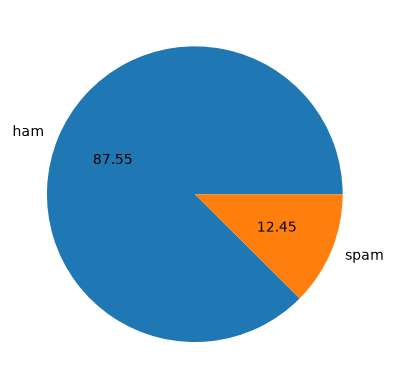

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.pie(df['label'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

The dataset is imbalanced, which can affect the performance of machine learning models, as they may become biased towards the majority class.

In [15]:
%pip install -q nltk

Note: you may need to restart the kernel to use updated packages.


In [16]:
import nltk

In [17]:
nltk.download('punkt') # punkt is pre-trained, unsupervised machine learning model used to detect sentence boundary.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arsal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
# create column to store the num_characters in sentences
df['characters'] = df['text'].apply(len)
df.sample(5)


,label,text,characters
4368,0,Anytime lor...,14
878,1,U have a secret admirer who is looking 2 make ...,132
927,0,K:)i will give my kvb acc details:),35
441,0,You were supposed to wake ME up >:(,35
3690,0,"Sir, i am waiting for your call, once free ple...",58


In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\arsal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
# create column to store the num_words in sentences
df['words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.sample(5)

,label,text,characters,words
5152,0,Idk. I'm sitting here in a stop and shop parki...,184,43
350,0,"Nah can't help you there, I've never had an ip...",50,13
4410,0,Ya but it cant display internal subs so i gott...,60,13
2085,0,Moji i love you more than words. Have a rich day,48,12
628,1,New TEXTBUDDY Chat 2 horny guys in ur area 4 j...,130,26


In [21]:
# create column to store the num_sentences for each entry
df['sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.sample(5)

,label,text,characters,words,sentences
4273,0,Ball is moving a lot.will spin in last :)so ve...,67,17,1
1117,1,"449050000301 You have won a å£2,000 price! To ...",70,14,2
1310,0,"I.ll always be there, even if its just in spir...",103,27,3
2873,0,Crucify is c not s. You should have told me ea...,52,12,1
4374,1,Ur TONEXS subscription has been renewed and yo...,146,27,3


In [22]:
# descriptive statistics on newly derived features
df[['characters', 'words', 'sentences']].describe()

,characters,words,sentences
count,5158.000000,5158.000000,5158.000000
mean,78.967623,18.325320,1.968592
std,57.950360,12.951979,1.453494
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,196.000000,38.000000


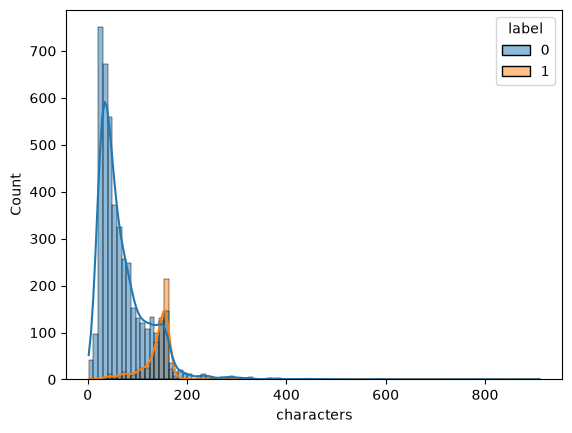

In [23]:
# plot combined histogram for different classes in label column for descriptive statistics

sns.histplot(data=df, x='characters', hue='label', kde=True)
plt.show()

### Spam signature analysis

Spam messages often exhibit unique stylometric signatures such as digit density (phone numbers, shortcodes, claim codes, monetary amounts), currency symbols (e.g., `£`, `$`, `€`, `¥`, `₹`) advertising cash prizes and web urls for phishing and redirects etc. 

These features can be leveraged to improve the accuracy of spam detection models.

In [24]:
import re

# extract spam signature features
df['digits'] = df['text'].apply(lambda x: sum(1 for c in x if c.isdigit()))

df['curSymbols'] = df['text'].apply(lambda x: len(re.findall(r'[\$£€¥₹]', x)))

df['capWords'] = df['text'].apply(lambda x: len([w for w in x.split() if w.isupper() and len(w) > 1]))

df['urls'] = df['text'].apply(lambda x: len(re.findall(r'https?://\S+|www\.\S+', x)))

# display sample with new spam signature features
df[['text', 'digits', 'curSymbols', 'capWords', 'urls', 'label']].sample(5)

,text,digits,curSymbols,capWords,urls,label
4145,I canåÕt wait for cornwall. Hope tonight isnåÕ...,0,0,0,0,0
176,U still going to the mall?,0,0,0,0,0
2241,U buy newspapers already?,0,0,0,0,0
4523,I've sent Ì_ my part..,0,0,1,0,0
3320,Yo im right by yo work,0,0,0,0,0


In [25]:
# comparative statistical summary between ham and spam
signature_features = ['characters', 'digits', 'curSymbols', 'capWords', 
                      'urls', 'label']

mean_comparison = df.groupby('label')[signature_features].mean().T
mean_comparison.columns = ['Ham', 'Spam']
mean_comparison['Ratio'] = mean_comparison['Spam'] / (mean_comparison['Ham'] + 1e-5)
display(mean_comparison)

,Ham,Spam,Ratio
characters,70.593003,137.876947,1.953125
digits,0.296723,15.442368,52.041330
curSymbols,0.005314,0.415888,78.109255
capWords,0.461692,2.323988,5.033525
urls,0.000221,0.133956,578.808068
label,0.000000,1.000000,100000.000000


## Data Preprocessing


In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arsal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
# convert stopwords list to a set once for o(1) constant time lookups
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # null and type safety check
    if not text or not isinstance(text, str):
        return ""
    
    # decode html entities and lowercase
    text = html.unescape(text).lower()

    # tokenize
    tokens = nltk.word_tokenize(text)

    # filter alphanumeric tokens
    tokens = [word for word in tokens if word.isalnum()]

    # remove stopwords and punctuation via list comprehension
    tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]

    # apply porter stemming
    tokens = [ps.stem(word) for word in tokens]

    return ' '.join(tokens)

In [28]:
# create a column preprocessedtext to store the text after data preprocessing
df['preprocessedText'] = df['text'].apply(preprocess_text)
df.sample(5)

,label,text,characters,words,sentences,digits,curSymbols,capWords,urls,preprocessedText
3672,0,Moji just informed me that you saved our lives...,55,12,2,0,0,0,0,moji inform save live thank
3472,0,You getting back any time soon?,31,7,1,0,0,0,0,get back time soon
5298,0,I.ll hand her my phone to chat wit u,36,9,1,0,0,0,0,hand phone chat wit u
752,0,Dont gimme that lip caveboy,27,6,1,0,0,0,0,dont gim lip caveboy
1069,0,Jus finish bathing...,21,4,1,0,0,0,0,ju finish bath


In [29]:
# create word cloud for different classes of label feature
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

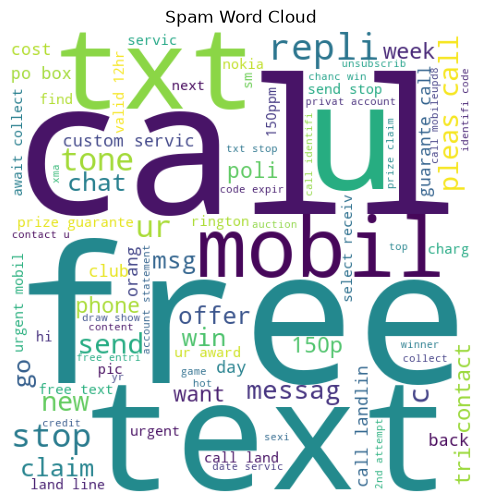

In [30]:
spam_wc = wc.generate(df[df['label']==1]['preprocessedText'].str.cat(sep=' '))

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.title('Spam Word Cloud')
plt.axis('off')
plt.show()

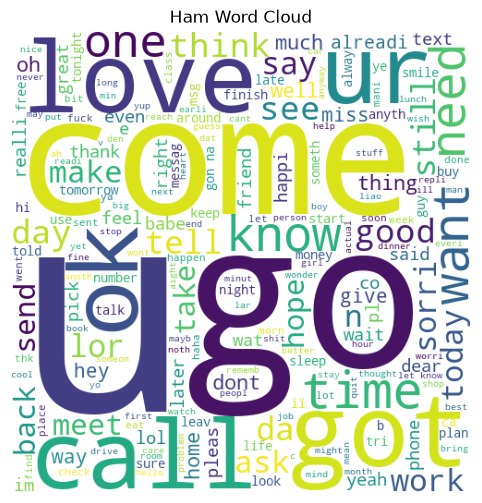

In [31]:
ham_wc = wc.generate(df[df['label']==0]['preprocessedText'].str.cat(sep=' '))

plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
plt.title('Ham Word Cloud')
plt.axis('off')
plt.show()

## Model Training and Evaluation

### Text Vectorization

In [36]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# raw stratified train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['preprocessedText'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# benchmark different vectorizers
vectorizers = {
    'Bag of Words': CountVectorizer(),
    'TF-IDF': TfidfVectorizer()
}

rep_results = []
for name, vec in vectorizers.items():
    X_tr = vec.fit_transform(X_train_raw)
    X_te = vec.transform(X_test_raw)
    
    clf = MultinomialNB()
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    
    rep_results.append({
        'Vectorizer': name,
        'Vocab Size': X_tr.shape[1],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_rep = pd.DataFrame(rep_results)
display(df_rep)

,Vectorizer,Vocab Size,Accuracy,Precision,Recall,F1-Score
0,Bag of Words,5952,0.978682,0.934426,0.890625,0.91200
1,TF-IDF,5952,0.960271,0.988764,0.687500,0.81106


In [37]:
# vectorize the preprocessed text using tf-idf
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X = tfidf.fit_transform(df['preprocessedText']).toarray()
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Train Class Balance: Ham={sum(y_train==0)}, Spam={sum(y_train==1)}")
print(f"Test Class Balance: Ham={sum(y_test==0)}, Spam={sum(y_test==1)}")

X_train shape: (4126, 3000) | X_test shape: (1032, 3000)
Train Class Balance: Ham=3612, Spam=514
Test Class Balance: Ham=904, Spam=128


### Model Selection

In [38]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Linear SVC': LinearSVC(random_state=42),
    'SVC (RBF Kernel)': SVC(kernel='rbf', probability=True, random_state=42),
}

model_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    model_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_models = pd.DataFrame(model_results)
display(df_models)

a:\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.970930,0.980392,0.781250,0.869565
1,Bernoulli Naive Bayes,0.978682,0.990741,0.835938,0.906780
2,Logistic Regression,0.962209,1.000000,0.695312,0.820276
3,Linear SVC,0.983527,0.982609,0.882812,0.930041
4,SVC (RBF Kernel),0.981589,1.000000,0.851562,0.919831


In [39]:
import joblib
from sklearn.svm import LinearSVC

# save the trained model
joblib.dump(models['Linear SVC'], 'linear_svc_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']